In [1]:
import xarray as xr
import torch
import pysindy as ps
from parametrizations import generate_dataloaders, NNpAEpD, process_past_timesteps
import math
import numpy as np
np.math = math
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.nn as nn
from torchmetrics.regression import R2Score
from tqdm import trange
import matplotlib.pyplot as plt
import os
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
L96 = xr.open_dataset('online_runs/ODE_Z/latent_dims=6_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=10000MTU_20260529162143.nc')

In [4]:
L96

<xarray.Dataset> Size: 720MB
Dimensions:  (time: 10000000, x: 8, y: 256)
Coordinates:
  * time     (time) float64 80MB 0.0 0.001 0.002 0.003 ... 1e+04 1e+04 1e+04
  * x        (x) int64 64B 0 1 2 3 4 5 6 7
  * y        (y) int64 2kB 0 1 2 3 4 5 6 7 8 ... 248 249 250 251 252 253 254 255
Data variables:
    X        (time, x) float32 320MB ...
    B        (time, x) float32 320MB ...

In [3]:
# True B
L96 = xr.open_dataset(f'online_runs/NO_PARAMETRIZATION/m=0.001_tau=0.001_t=10000MTU_20250903172407.nc')
coord = 4
X = L96.X.values[:, coord]
B = L96.B.values[:, coord]

In [6]:
model1 = torch.load('hyper_opt/latent_dims=6/m=0.001_tau=0.001_hyper_opt_w=0.001_20260529133148.pkl', weights_only=False)
model2 = torch.load('hyper_opt/latent_dims=6/m=0.001_tau=0.001_hyper_opt_w=0.0001_20260529133549.pkl', weights_only=False)

In [ ]:
_, testloader = generate_dataloaders(L96, model1, train_share=.5)

499.8
499.8


In [6]:
dir = 'hyper_opt/initial_pt_tests/'
for file in os.listdir(dir):
    print(file)
    if 'pkl' in file:
        model1 = torch.load(dir + file, weights_only=False)
        _, testloader = generate_dataloaders(L96, model1, train_share=.5)
        b_trues, b_preds = [], []
        with torch.no_grad():
            for x_batch, b_batch in testloader:
                # Preprocessing
                x_batch, b_batch = process_past_timesteps(x_batch, b_batch, past_timesteps=model1.past_timesteps)
                b_pred, _ = model1(x_batch)
                b_trues.append(b_batch)
                b_preds.append(b_pred)

        b_trues = torch.cat(b_trues, dim=0)
        b_preds = torch.cat(b_preds, dim=0)
        R2 = R2Score()(b_preds, b_trues)
        model1.R2.append(R2.item())
        model1.save(additional_info=f'hyper_opt_offline_R2_w={model1.weight_decay}_dz={model1.latent_dims}')

m=0.001_tau=0.001_init_hyper_opt_pt=1000_20260603150535.pkl
499.8
499.8
m=0.001_tau=0.001_init_hyper_opt_pt=1000_20260603132655.pkl
499.8
499.8
m=0.001_tau=0.001_init_hyper_opt_pt=10_20260603131555.pkl
499.899
499.899
m=0.001_tau=0.001_init_hyper_opt_pt=100_20260603145753.pkl
499.89
499.89
summary_latex_table
m=0.001_tau=0.001_init_hyper_opt_pt=10_20260603145428.pkl
499.899
499.899
m=0.001_tau=0.001_init_hyper_opt_pt=100_20260603131920.pkl
499.89
499.89


In [ ]:
mode
_, testloader = generate_dataloaders(L96, model1, train_share=.5)
b_trues, b_preds = [], []
with torch.no_grad():
    for x_batch, b_batch in testloader:
        # Preprocessing
        x_batch, b_batch = process_past_timesteps(x_batch, b_batch, past_timesteps=1000)
        b_pred, _ = model1(x_batch)
        b_trues.append(b_batch)
        b_preds.append(b_pred)

b_trues = torch.cat(b_trues, dim=0)
b_preds = torch.cat(b_preds, dim=0)
R2 = R2Score()(b_preds, b_trues)
model1.R2.append(R2.item())


In [24]:
b_trues = torch.cat(b_trues, dim=0)
b_preds = torch.cat(b_preds, dim=0)

In [27]:
R2Score()(b_preds, b_trues)

tensor(0.9322, device='cuda:0')

In [2]:
L96 = xr.open_dataset('online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=10000MTU_hyper_opt_w=0.0_20260527175735.nc')
L96

<xarray.Dataset> Size: 6GB
Dimensions:      (time: 10000000, x: 8, latent_dims: 8, y: 256)
Coordinates:
  * time         (time) float64 80MB 0.0 0.001 0.002 0.003 ... 1e+04 1e+04 1e+04
  * x            (x) int64 64B 0 1 2 3 4 5 6 7
  * latent_dims  (latent_dims) int64 64B 0 1 2 3 4 5 6 7
  * y            (y) int64 2kB 0 1 2 3 4 5 6 7 ... 249 250 251 252 253 254 255
Data variables:
    X            (time, x) float32 320MB ...
    B            (time, x) float32 320MB ...
    Z            (time, x, latent_dims) float64 5GB ...

In [49]:
### Load training data XZ
L96 = xr.open_dataset('online_runs/NN+AE+D/latent_dims=8_past_timesteps=1000_n_neighbours=0/m=0.001_tau=0.001_t=10000MTU_hyper_opt_w=0.0_20260527175735.nc')
coord = 4
Z = L96.Z.values[:, coord, :]
X = L96.X.values[:, coord].reshape(-1, 1)
Nt = len(X)
Ntrain = int(0.8 * Nt)
X_train, X_test = X[:Ntrain], X[Ntrain:]
Z_train, Z_test = Z[:Ntrain], Z[Ntrain:]

fd=ps.FiniteDifference()
Zdot_train = fd._differentiate(Z_train, t=.001)
Zdot_test = fd._differentiate(Z_test, t=.001)

In [ ]:
# --- Lower bound ---
# z_train = [Z_train[:, k, :] for k in range(8)]
# z_test = [Z_test[:, k, :] for k in range(8)]
# x_train = [X_train[:, k].reshape(-1, 1) for k in range(8)]
# x_test = [X_test[:, k].reshape(-1, 1) for k in range(8)]

In [79]:
# Set SINDy parameters
diff_method = ps.FiniteDifference()

# Learn ODE without other Z_k variables
opt = ps.STLSQ(threshold=0.0)
lib = ps.PolynomialLibrary(degree=1)
model = ps.SINDy(feature_library=lib, 
                differentiation_method=diff_method, 
                optimizer=opt)

model.fit(x=Z_train, u=X_train, x_dot=Zdot_train, t=.001)
model.print()  
score = model.score(x=Z_test, x_dot=Zdot_test, u=X_test, t=.001, multioutput='raw_values')
print('Model score: ', score, flush=True)

(x0)' =  3.373 1 + -0.301 x0 +  3.654 x1 +  5.910 x2 + -2.944 x3 + -1.236 x4 +  3.280 x5 +  0.114 x6 +  2.201 x7 +  12.104 u0
(x1)' = -88.260 1 + -9.275 x0 + -7.818 x1 +  1.422 x2 +  7.580 x3 +  10.435 x4 + -7.439 x5 +  2.042 x6 + -0.130 x7 + -32.799 u0
(x2)' =  10.743 1 + -7.986 x0 + -2.983 x1 + -3.152 x2 +  4.325 x3 + -0.474 x4 + -0.507 x5 + -1.219 x6 + -3.106 x7 + -30.028 u0
(x3)' = -5.060 1 +  3.667 x0 +  0.831 x1 +  0.131 x2 + -5.209 x3 +  0.051 x4 +  10.500 x5 + -0.014 x6 + -3.343 x7 +  42.031 u0
(x4)' =  41.892 1 + -2.274 x0 + -12.465 x1 +  9.584 x2 + -3.484 x3 + -0.215 x4 + -0.147 x5 +  6.558 x6 +  11.712 x7 +  33.895 u0
(x5)' = -21.389 1 + -0.735 x0 +  2.028 x1 + -4.672 x2 + -4.415 x3 + -1.747 x4 + -1.007 x5 + -8.389 x6 + -1.912 x7 + -28.587 u0
(x6)' =  3.466 1 +  1.934 x0 +  1.215 x1 + -2.737 x2 +  4.345 x3 + -0.573 x4 +  0.778 x5 + -5.121 x6 + -10.663 x7 + -41.997 u0
(x7)' =  28.033 1 + -3.950 x0 +  1.134 x1 +  2.906 x2 +  3.824 x3 + -1.013 x4 + -0.052 x5 +  8.801 x6 +  0.47

In [56]:
Zdot_pred_linear = model.predict(x=Z_test, u=X_test)

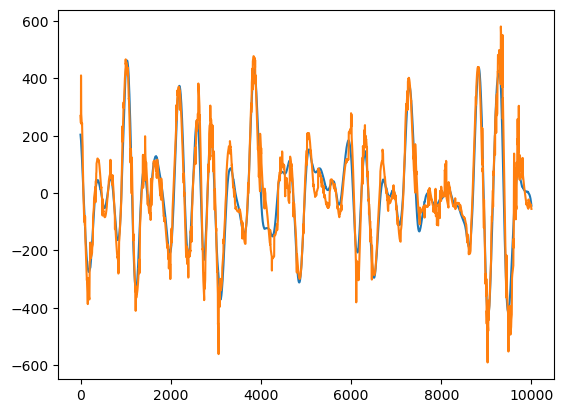

In [62]:
plt.plot(Zdot_pred_linear[:10_000, 4])
plt.plot(Zdot_test[:10_000, 4])

In [63]:
Zdot_train_torch = torch.tensor(Zdot_train, dtype=torch.float32, device=device)
Zdot_test_torch = torch.tensor(Zdot_test, dtype=torch.float32, device=device)
Z_train_torch = torch.tensor(Z_train, dtype=torch.float32, device=device)
Z_test_torch = torch.tensor(Z_test, dtype=torch.float32, device=device)
X_train_torch = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test_torch = torch.tensor(X_test, dtype=torch.float32, device=device)

In [64]:
XZ_train = torch.cat((X_train_torch, Z_train_torch), dim=-1)
XZ_test = torch.cat((X_test_torch, Z_test_torch), dim=-1)

In [81]:
class NN_predictability(nn.Module):
    def __init__(self, latent_dims, n_forcings, nodes_per_layer=16):
        nn.Module.__init__(self)
        self.latent_dims = latent_dims
        self.n_forcings = n_forcings
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NN_predictability'

        self.neural_net = nn.Sequential(
            nn.Linear(self.latent_dims + self.n_forcings, self.nodes_per_layer), 
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, latent_dims)
        )

        self.train_loss = []
        self.test_loss = []
        self.R2 = []
    
    def forward(self, x):
        y_pred = self.neural_net(x)
        return y_pred

In [82]:
model = NN_predictability(latent_dims=8, n_forcings=1)

In [83]:
model = model.to(device)
criterion = nn.MSELoss()
lr = .007
num_epochs = 3000
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Make progress bar
best_R2 = float('-inf')
best_R2_epoch = 0
pbar = trange(num_epochs, desc="Training", ncols=150)

# Training
for epoch in pbar:
    model.train()

    # Transpose 1-dimensional data
    dZdt_pred = model.forward(XZ_train)
    loss = criterion(dZdt_pred, Zdot_train_torch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss = loss.item() / len(XZ_train)
    
    model.eval()
    with torch.no_grad():
        # Transpose 1-dimensional data
        dZdt_pred = model.forward(XZ_test)
        loss = criterion(dZdt_pred, Zdot_test_torch)
        R2 = R2Score(multioutput='raw_values').to(device)(dZdt_pred, Zdot_test_torch).detach().cpu().numpy()
        test_loss = loss.item() / len(XZ_test)
    

    model.train_loss.append(train_loss)
    model.test_loss.append(test_loss)
    model.R2.append(R2)

    # Inline update
    pbar.set_postfix({
        "Train Loss": f"{train_loss:.6f}",
        "Test Loss": f"{test_loss:.6f}",
        "R²": f"{np.min(R2):.4f}, {np.mean(R2):.4f}"})

Training: 100%|███████████████████████████████████████| 3000/3000 [03:40<00:00, 13.58it/s, Train Loss=0.000138, Test Loss=0.000532, R²=0.8462, 0.9185]


In [89]:
R2s = np.array(model.R2)
best_worst_variable = np.argmax(np.min(R2s, axis=1))
R2s[best_worst_variable]

array([0.86419857, 0.8633987 , 0.95836854, 0.9277    , 0.9513005 ,
       0.96336234, 0.94970423, 0.91004777], dtype=float32)

In [92]:
Zdot_pred_NN = model.forward(XZ_test).detach().cpu().numpy()

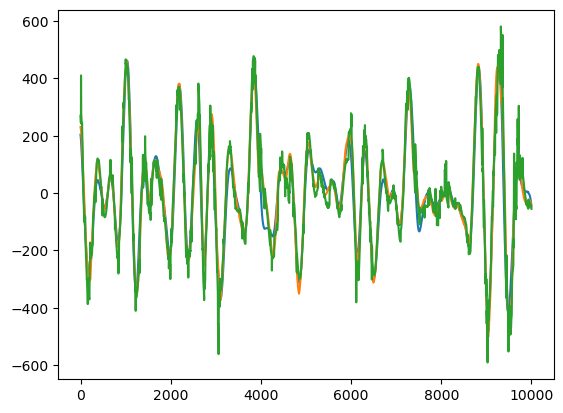

In [93]:
plt.plot(Zdot_pred_linear[:10_000, 4])
plt.plot(Zdot_pred_NN[:10_000, 4])
plt.plot(Zdot_test[:10_000, 4])